# A0. Brain-aligned vs brain-orthogonal subspace of SigLIP

Splits the 1152-d SigLIP space into:
- **Brain-aligned subspace** — directions the neural encoder reliably recovers (top-k left singular vectors of the cross-covariance `gt.T @ pred`)
- **Brain-orthogonal complement** — everything the visual system discards

**Model:** category-conditioned obj encoder. GT = bbox-crop SigLIP.

k chosen by permutation null (consecutive components above null p95).

### Primary metric: axis readout Pearson r (adapted from Tuckute et al. 2024)

For each semantic axis **v** (unit vector in SigLIP space), compute:

```
r_axis = Pearson(gt @ v, pred @ v)   across N=90 test stimuli
```

This directly asks: *does the neural encoder preserve the brain's projection onto this axis?*
High r → the brain encodes this axis. Low r → the brain discards it.
Equivalent to Tuckute's encoding model Pearson r, but generalised to multivariate SigLIP output and evaluated per semantic axis rather than per sentence.

### Geometric decomposition: subspace squared cosine

`subspace_sq_cos(v, Uk) = ‖Uk.T @ v‖²` — fraction of v's energy in the brain-aligned subspace.
Complements r_axis: tells you *where* in the 1152-d space the axis lies, not just whether it's recovered.

**Key figures:**
1. Scree plot vs permutation null → selected k
2. Cumulative GT variance captured vs k
3. 4-panel bar chart: r_axis | aligned sq-cos | orthogonal sq-cos | effect size


In [11]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from config_const import (
    SEED, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, HVM_SIGLIP_EMBEDDINGS_PATH,
    HVM_METADATA_PATH, HVM_CATEGORIES, HVM_N_VAR,
)
from data_utils.hvm_loader import _load_hvm_neural, _category_stratified_split
from encoders.multihead import MultiHeadTransformer
from get_device import get_device

DEVICE = get_device()
_, _, test_idx = _category_stratified_split(SEED)
test_idx = list(test_idx)
N = len(test_idx)
cat_ids_np = np.array([ti // HVM_N_VAR for ti in test_idx])  # (90,)
print(f'Test set: {N} stimuli')

Test set: 90 stimuli


In [12]:
# GT = bbox-crop SigLIP (obj model target)
siglip_obj_all = torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True).float()  # (450, 1152)
gt = F.normalize(siglip_obj_all[test_idx], dim=-1).numpy()   # (90, 1152)

# Category-conditioned obj encoder
cfg = json.load(open('cache/best_hvm_multihead_obj_config.json'))
ckpt = torch.load(cfg['checkpoint'], weights_only=False, map_location='cpu')
args = ckpt['args']
print('use_category:', args['use_category'])   # should be True

rsp, _, _ = _load_hvm_neural(area='all')
rsp_t = torch.tensor(rsp[test_idx], dtype=torch.float32).permute(0, 2, 1)  # (90, T, N)

model = MultiHeadTransformer(
    n_neurons=rsp_t.shape[2],
    d_model=args['d_model'], n_heads=args['n_heads'],
    n_layers=args['n_layers'], shared_dim=args['shared_dim'],
    dropout=args['dropout'], n_categories=10,
)
model.load_state_dict(ckpt['model_state'])
model.eval()

cat_t = torch.tensor(cat_ids_np, dtype=torch.long)
with torch.no_grad():
    pred = model(rsp_t, cat=cat_t)['siglip'].numpy()  # (90, 1152)
pred = pred / np.linalg.norm(pred, axis=1, keepdims=True)

print(f'gt: {gt.shape}  pred: {pred.shape}')
print(f'Baseline cos-sim (obj, cat-conditioned): {(pred * gt).sum(axis=1).mean():.4f}')


use_category: True


Loading HVM sessions:   0%|          | 0/5 [00:00<?, ?it/s]

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.57it/s]


gt: (90, 1152)  pred: (90, 1152)
Baseline cos-sim (obj, cat-conditioned): 0.8854


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 1. Cross-covariance SVD and permutation null

`C = gt.T @ pred` is (1152, 1152) but rank ≤ N=90. Only the first N singular values carry signal. k = number of *consecutive* leading components above null p95.

In [13]:
N_PERMS = 1000
rng = np.random.default_rng(SEED)

C = gt.T @ pred
U_full, S_all, _ = np.linalg.svd(C, full_matrices=False)
K_MAX = N
S_full = S_all[:K_MAX]
U_full = U_full[:, :K_MAX]  # (1152, 90)

S_null = np.zeros((N_PERMS, K_MAX))
for p in range(N_PERMS):
    _, s, _ = np.linalg.svd(gt.T @ pred[rng.permutation(N)], full_matrices=False)
    S_null[p] = s[:K_MAX]
    if (p + 1) % 200 == 0:
        print(f'  perm {p+1}/{N_PERMS}')

null_p95 = np.percentile(S_null, 95, axis=0)
null_p05 = np.percentile(S_null,  5, axis=0)
null_p50 = np.percentile(S_null, 50, axis=0)

sig_mask = S_full > null_p95
k_best = int(np.argmin(sig_mask)) if not sig_mask.all() else K_MAX

print(f'\nk = {k_best} (consecutive components above null p95)')
print(f'Actual S (top 15): {np.round(S_full[:15], 2)}')
print(f'Null p95 (top 15): {np.round(null_p95[:15], 2)}')

  perm 200/1000
  perm 400/1000
  perm 600/1000
  perm 800/1000
  perm 1000/1000

k = 10 (consecutive components above null p95)
Actual S (top 15): [59.97  4.16  3.23  2.92  2.63  1.99  1.91  1.63  1.41  1.13  0.5   0.39
  0.24  0.17  0.14]
Null p95 (top 15): [59.96  1.9   1.55  1.3   1.13  1.    0.87  0.78  0.69  0.61  0.51  0.41
  0.34  0.27  0.21]


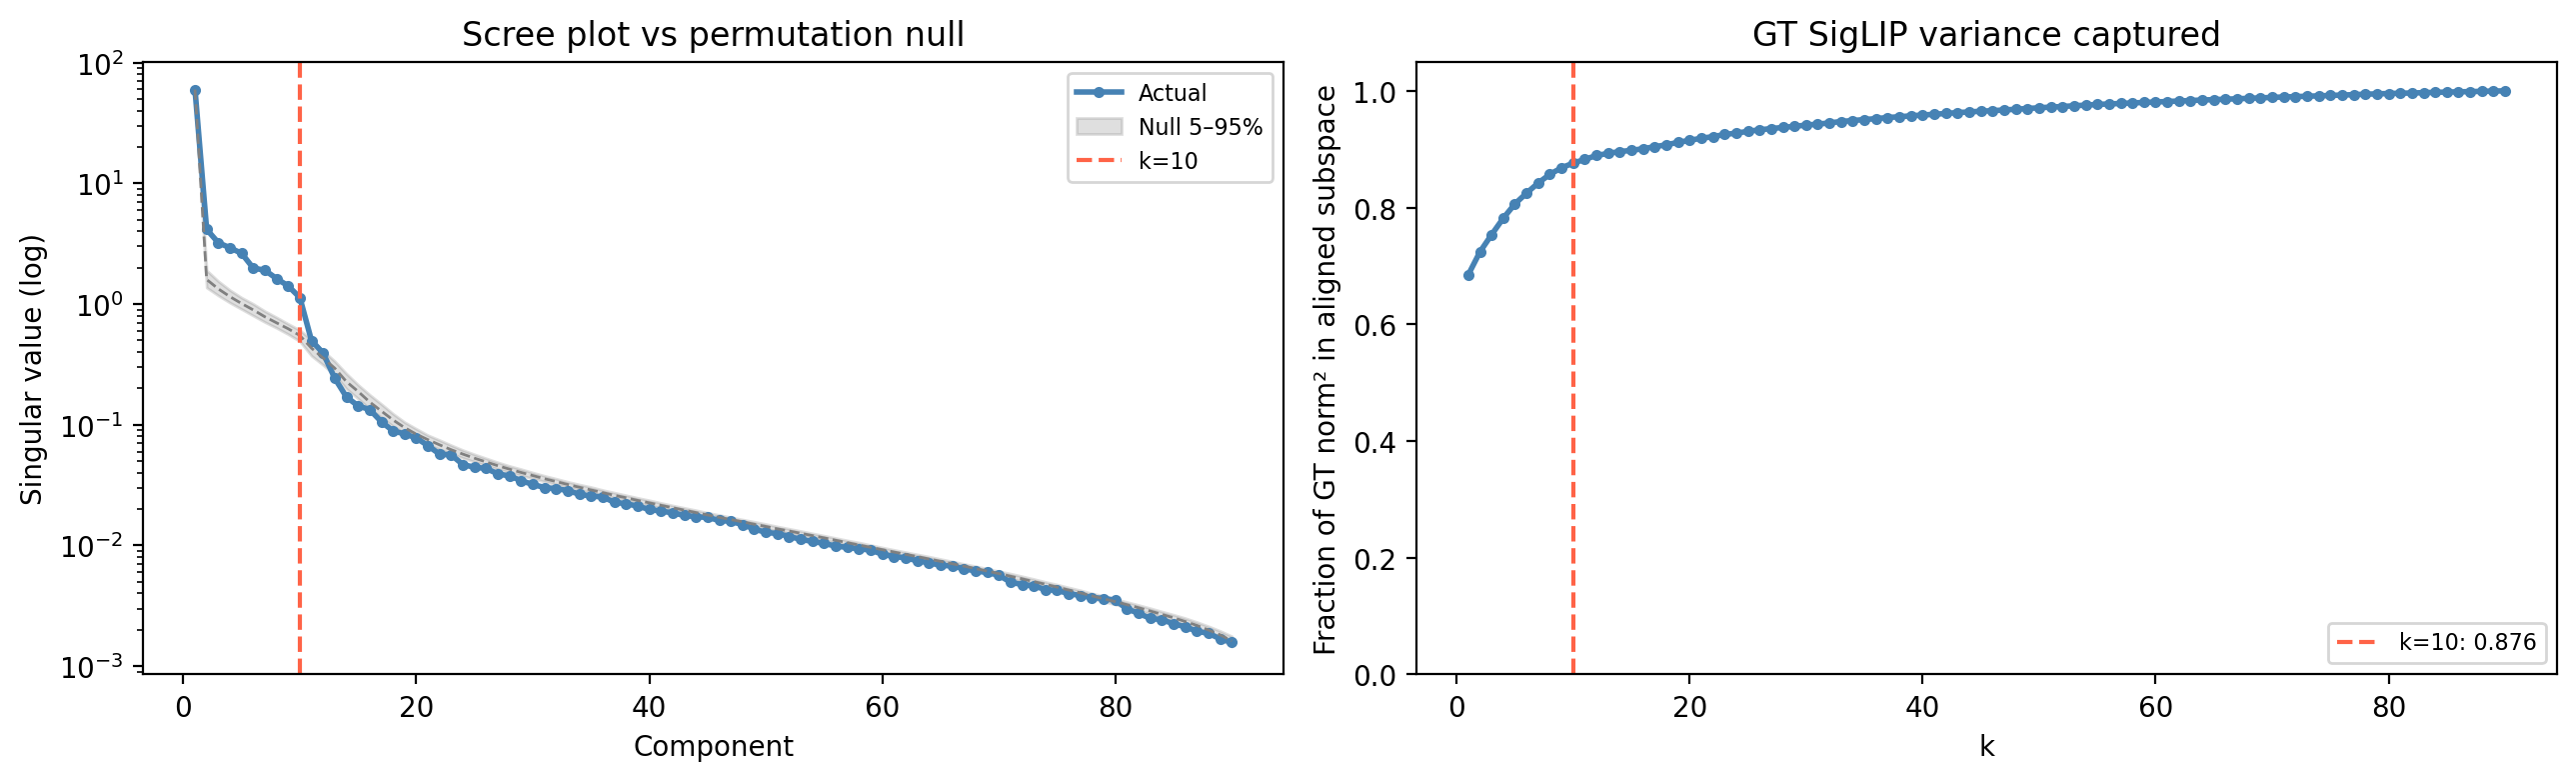

At k=10: 0.876 of GT variance is brain-aligned


In [14]:
ks = np.arange(1, K_MAX + 1)

gt_var_frac = np.array([
    np.mean(np.linalg.norm(gt @ U_full[:, :k] @ U_full[:, :k].T, axis=1) ** 2)
    for k in ks
]) / np.mean(np.linalg.norm(gt, axis=1) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogy(ks, S_full, 'o-', ms=3, color='steelblue', lw=2, label='Actual')
ax.fill_between(ks, null_p05, null_p95, alpha=0.25, color='grey', label='Null 5–95%')
ax.semilogy(ks, null_p50, '--', color='grey', lw=1)
ax.axvline(k_best, color='tomato', ls='--', lw=1.5, label=f'k={k_best}')
ax.set_xlabel('Component')
ax.set_ylabel('Singular value (log)')
ax.set_title('Scree plot vs permutation null')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(ks, gt_var_frac, 'o-', ms=3, color='steelblue', lw=2)
ax.axvline(k_best, color='tomato', ls='--', lw=1.5,
           label=f'k={k_best}: {gt_var_frac[k_best-1]:.3f}')
ax.set_xlabel('k')
ax.set_ylabel('Fraction of GT norm² in aligned subspace')
ax.set_title('GT SigLIP variance captured')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'At k={k_best}: {gt_var_frac[k_best-1]:.3f} of GT variance is brain-aligned')

## 2. Project GT onto aligned / orthogonal subspaces

In [15]:
K = k_best
Uk      = U_full[:, :K]   # (1152, K)  brain-aligned basis
U_orthog = U_full[:, K:]  # (1152, 90-K)

gt_aligned = gt @ Uk @ Uk.T
gt_orthog  = gt - gt_aligned

gt_aligned_n = gt_aligned / (np.linalg.norm(gt_aligned, axis=1, keepdims=True) + 1e-12)
gt_orthog_n  = gt_orthog  / (np.linalg.norm(gt_orthog,  axis=1, keepdims=True) + 1e-12)

var_a = (np.linalg.norm(gt_aligned, axis=1) ** 2).mean()
var_o = (np.linalg.norm(gt_orthog,  axis=1) ** 2).mean()
print(f'K = {K}')
print(f'Energy aligned:    {var_a/(var_a+var_o):.3f}')
print(f'Energy orthogonal: {var_o/(var_a+var_o):.3f}')

cos_a = (gt_aligned_n * gt).sum(axis=1)
cos_o = (gt_orthog_n  * gt).sum(axis=1)
print(f'Cos-sim aligned  → GT: {cos_a.mean():.4f} ± {cos_a.std()/np.sqrt(N):.4f}')
print(f'Cos-sim orthog   → GT: {cos_o.mean():.4f} ± {cos_o.std()/np.sqrt(N):.4f}')

K = 10
Energy aligned:    0.876
Energy orthogonal: 0.124
Cos-sim aligned  → GT: 0.9355 ± 0.0034
Cos-sim orthog   → GT: 0.3437 ± 0.0080


## 3. Semantic axes: between-category and within-category

**Between-category axes** (Δ category-mean SigLIP vectors): test whether the aligned subspace captures gross categorical distinctions.

**Within-category axes** (from rendering metadata — rotation, size, translation): test whether the aligned subspace captures fine-grained variation *within* a category. If within-category axes land in the orthogonal subspace, the brain encodes category identity but discards within-category detail — a direct neuroscience finding that cannot be confused with category memorization.

In [16]:
# ── Between-category axes ────────────────────────────────────────────────────
# Use all 450 stimuli for stable category means
gt_all  = F.normalize(siglip_obj_all, dim=-1).numpy()  # (450, 1152)
cat_all = np.arange(450) // HVM_N_VAR

cat_means = np.stack([
    gt_all[cat_all == c].mean(axis=0) for c in range(10)
])  # (10, 1152)
cat_means /= np.linalg.norm(cat_means, axis=1, keepdims=True)

# HVM_CATEGORIES = ('apple','bear','car','chair','dog','elephant','head','plane','table','turtle')
def between_axis(pos_ids, neg_ids):
    v = cat_means[pos_ids].mean(axis=0) - cat_means[neg_ids].mean(axis=0)
    norm = np.linalg.norm(v)
    return v / (norm + 1e-12), float(norm)

BETWEEN_AXES  = {}   # name -> unit vector
BETWEEN_NORMS = {}   # name -> raw norm (axis strength)
for name, (pos, neg) in [
    ('Δ animate−inanimate',       ([1,4,5,6,9], [0,2,3,7,8])),
    ('Δ face−non-face',           ([6], [0,1,2,3,4,5,7,8,9])),
    ('Δ vehicle−non-vehicle',     ([2,7], [0,1,3,4,5,6,8,9])),
    ('Δ furniture−non-furniture', ([3,8], [0,1,2,4,5,6,7,9])),
    ('Δ round−elongated',         ([0,1,4,5,9], [2,3,7,8])),
]:
    vec, norm = between_axis(pos, neg)
    BETWEEN_AXES[name]  = vec
    BETWEEN_NORMS[name] = norm

print('Between-category axes:', list(BETWEEN_AXES.keys()))


Between-category axes: ['Δ animate−inanimate', 'Δ face−non-face', 'Δ vehicle−non-vehicle', 'Δ furniture−non-furniture', 'Δ round−elongated']


In [17]:
# ── Within-category axes from rendering metadata ──────────────────────────────
meta = json.load(open(HVM_METADATA_PATH))  # list of 450 dicts

WITHIN_PARAMS = {
    'Δ rotation (rxy)':   'rxy',
    'Δ rotation (rxz)':   'rxz',
    'Δ size (s)':          's',
    'Δ translation (ty)': 'ty',
    'Δ translation (tz)': 'tz',
}

def within_axis(param_key):
    """For each category, split on median of param_key, take mean-SigLIP difference.
    Returns (unit_vector, mean_raw_norm_across_categories)."""
    cat_axes = []
    cat_norms = []
    for c in range(10):
        idx_c = np.where(cat_all == c)[0]
        vals  = np.array([meta[i][param_key] for i in idx_c])
        med   = np.median(vals)
        high  = idx_c[vals >= med]
        low   = idx_c[vals <  med]
        if len(high) == 0 or len(low) == 0:
            continue
        diff = gt_all[high].mean(axis=0) - gt_all[low].mean(axis=0)
        norm = np.linalg.norm(diff)
        cat_norms.append(norm)
        if norm > 1e-8:
            cat_axes.append(diff / norm)
    avg = np.stack(cat_axes).mean(axis=0)
    unit = avg / (np.linalg.norm(avg) + 1e-12)
    return unit, float(np.mean(cat_norms))

WITHIN_AXES  = {}
WITHIN_NORMS = {}
for name, pk in WITHIN_PARAMS.items():
    vec, norm = within_axis(pk)
    WITHIN_AXES[name]  = vec
    WITHIN_NORMS[name] = norm

print('Within-category axes:', list(WITHIN_AXES.keys()))


Within-category axes: ['Δ rotation (rxy)', 'Δ rotation (rxz)', 'Δ size (s)', 'Δ translation (ty)', 'Δ translation (tz)']


In [18]:
from scipy.stats import pearsonr

def subspace_sq_cos(axis_vec, basis):
    """Fraction of axis_vec's squared norm that lies in the subspace spanned by basis (orthonormal cols)."""
    proj = basis.T @ axis_vec
    return float((proj ** 2).sum())

# Mean pairwise L2 distance across all 450 GT embeddings — natural scale of SigLIP space
diffs = gt_all[:, None, :] - gt_all[None, :, :]
pairwise_dist = np.sqrt((diffs ** 2).sum(axis=-1))
mean_pdist = pairwise_dist[np.triu_indices(450, k=1)].mean()
print(f'Mean pairwise L2 distance in SigLIP space: {mean_pdist:.4f}')

null_aligned = K / 1152
null_orthog  = (1152 - K) / 1152

def score_axes(axes_dict, norms_dict):
    """For each axis v:
      - aligned / orthog: fraction of v in each subspace (geometry)
      - r_axis: Pearson r between gt@v and pred@v on the 90 test stimuli
                (Tuckute-style readout: does the brain encode this axis?)
      - strength: raw L2 norm of the mean-difference vector (axis magnitude in SigLIP)
      - effect: strength / mean_pdist (relative to typical object separation)
    """
    results = {}
    for name, vec in axes_dict.items():
        sq_a     = subspace_sq_cos(vec, Uk)
        sq_o     = subspace_sq_cos(vec, U_orthog)
        strength = norms_dict[name]
        effect   = strength / mean_pdist
        r_axis, p_axis = pearsonr(gt @ vec, pred @ vec)
        results[name] = dict(aligned=sq_a, orthog=sq_o,
                             r_axis=r_axis, p_axis=p_axis,
                             strength=strength, effect=effect)
        print(f'{name:35s}  r={r_axis:+.3f} (p={p_axis:.3f})  '
              f'aligned={sq_a:.3f}  orthog={sq_o:.3f}  effect={effect:.3f}')
    return results

print(f'Null: aligned={null_aligned:.3f}  orthog={null_orthog:.3f}\n')
print('── Between-category ──')
between_results = score_axes(BETWEEN_AXES, BETWEEN_NORMS)
print('\n── Within-category ──')
within_results  = score_axes(WITHIN_AXES, WITHIN_NORMS)


Mean pairwise L2 distance in SigLIP space: 0.7780
Null: aligned=0.009  orthog=0.991

── Between-category ──
Δ animate−inanimate                  r=+0.979 (p=0.000)  aligned=0.953  orthog=0.027  effect=0.446
Δ face−non-face                      r=+0.908 (p=0.000)  aligned=0.932  orthog=0.042  effect=0.624
Δ vehicle−non-vehicle                r=+0.966 (p=0.000)  aligned=0.966  orthog=0.016  effect=0.582
Δ furniture−non-furniture            r=+0.968 (p=0.000)  aligned=0.952  orthog=0.024  effect=0.528
Δ round−elongated                    r=+0.984 (p=0.000)  aligned=0.963  orthog=0.019  effect=0.512

── Within-category ──
Δ rotation (rxy)                     r=+0.657 (p=0.000)  aligned=0.176  orthog=0.639  effect=0.228
Δ rotation (rxz)                     r=+0.733 (p=0.000)  aligned=0.115  orthog=0.531  effect=0.172
Δ size (s)                           r=+0.550 (p=0.000)  aligned=0.110  orthog=0.750  effect=0.211
Δ translation (ty)                   r=+0.344 (p=0.001)  aligned=0.028  ortho

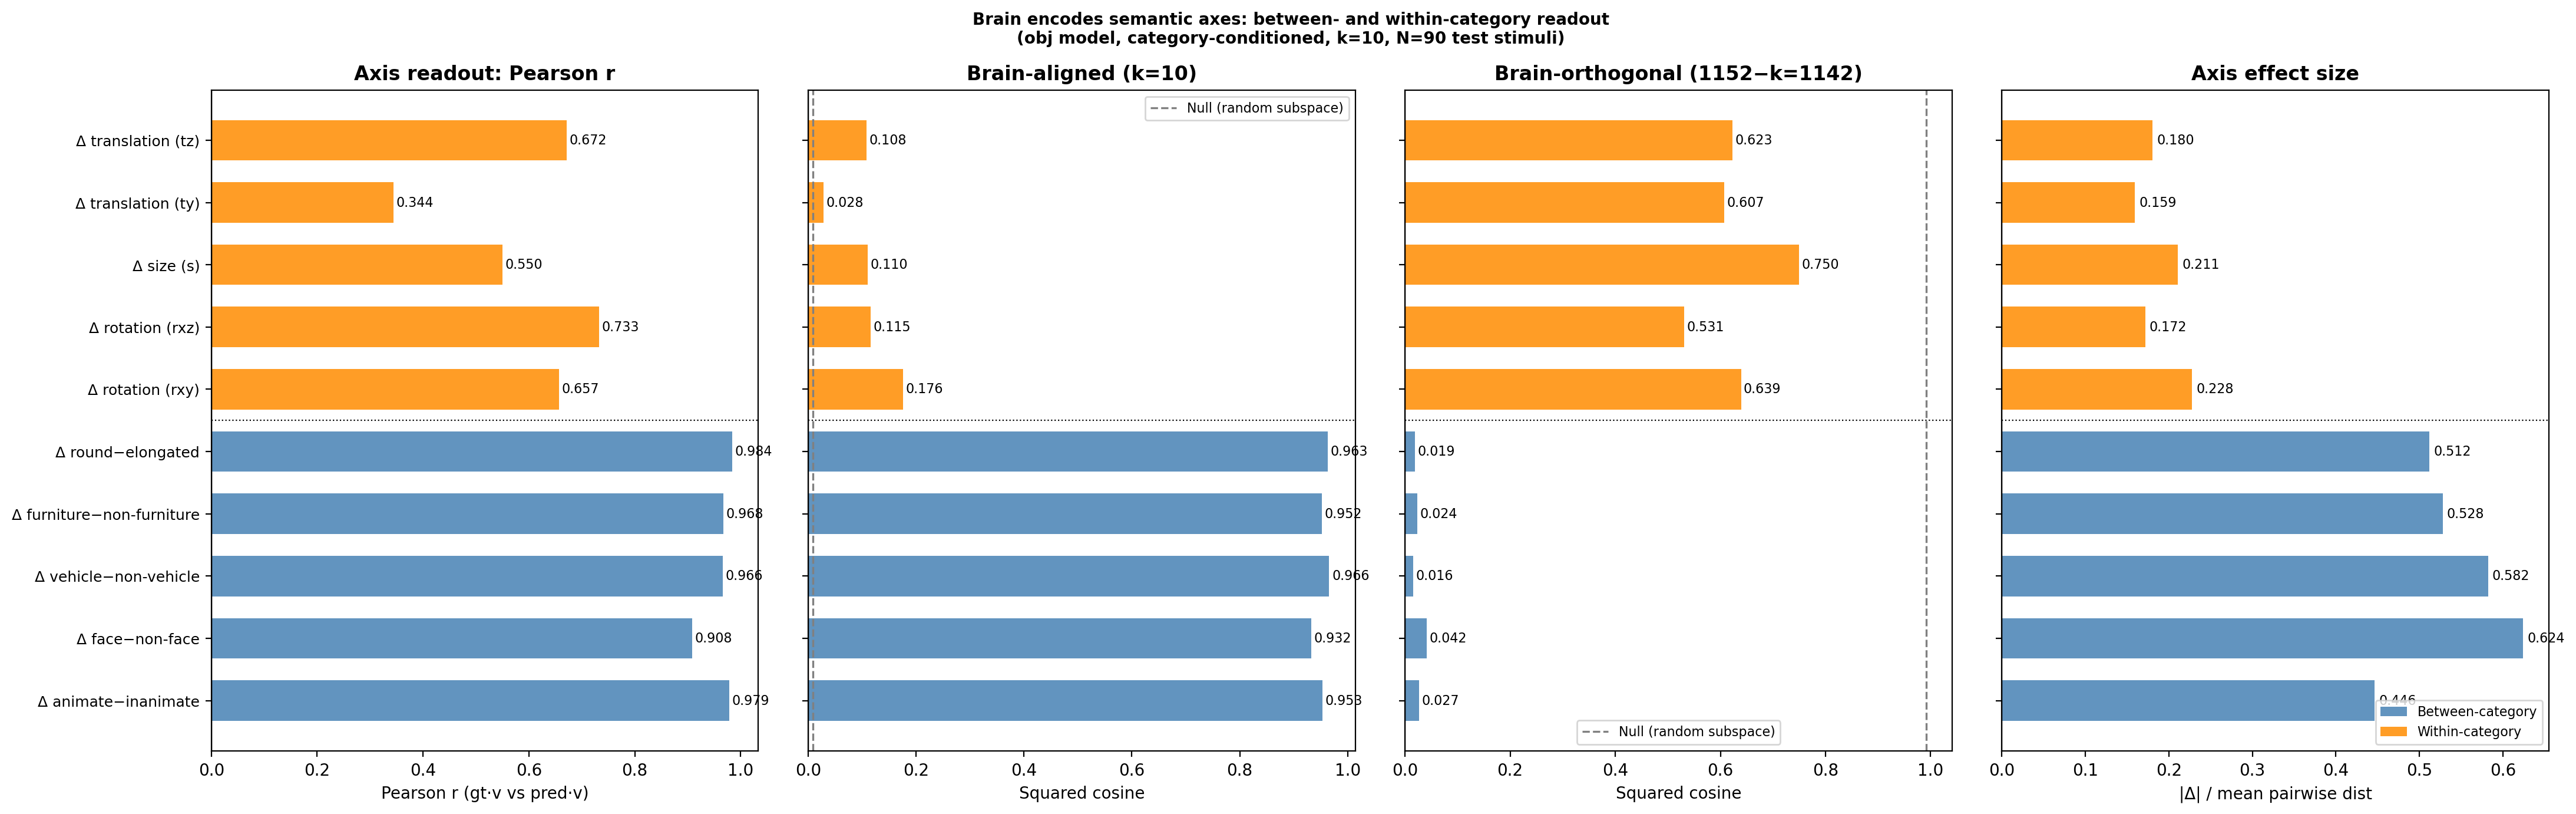

In [19]:
# ── Figure: 4-panel bar chart ─────────────────────────────────────────────────
# Panel 1: Pearson r (gt@v vs pred@v) — primary metric (Tuckute-style axis readout)
# Panel 2: squared cosine onto brain-aligned subspace (where the signal lives)
# Panel 3: squared cosine onto brain-orthogonal complement
# Panel 4: axis effect size = |Δ| / mean pairwise L2 dist (how big the axis is)

all_results = dict(**between_results, **within_results)
names_b = list(between_results.keys())
names_w = list(within_results.keys())
all_names = names_b + names_w

r_vals         = [all_results[n]['r_axis']  for n in all_names]
sq_aligned_all = [all_results[n]['aligned'] for n in all_names]
sq_orthog_all  = [all_results[n]['orthog']  for n in all_names]
effects        = [all_results[n]['effect']  for n in all_names]

bar_colors = ['steelblue'] * len(names_b) + ['darkorange'] * len(names_w)

fig, axes_ax = plt.subplots(1, 4, figsize=(22, max(4, len(all_names) * 0.55 + 1.5)),
                             sharey=True)
y   = np.arange(len(all_names))
sep = len(names_b) - 0.5

panels = [
    (axes_ax[0], r_vals,         None,         f'Axis readout: Pearson r',              'Pearson r (gt·v vs pred·v)'),
    (axes_ax[1], sq_aligned_all, null_aligned, f'Brain-aligned (k={K})',                'Squared cosine'),
    (axes_ax[2], sq_orthog_all,  null_orthog,  f'Brain-orthogonal (1152−k={1152-K})',   'Squared cosine'),
    (axes_ax[3], effects,        None,          'Axis effect size',                      '|Δ| / mean pairwise dist'),
]

for ax, vals, null_val, title, xlabel in panels:
    bars = ax.barh(y, vals, color=bar_colors, alpha=0.85, height=0.65)
    if null_val is not None:
        ax.axvline(null_val, color='grey', ls='--', lw=1.2, label='Null (random subspace)')
        ax.legend(fontsize=8)
    ax.axvline(0, color='black', lw=0.5)
    ax.axhline(sep, color='black', lw=0.8, ls=':')
    for bar, v in zip(bars, vals):
        offset = 0.005 if v >= 0 else -0.005
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + offset, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', ha=ha, fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(all_names, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='steelblue',  alpha=0.85, label='Between-category'),
    Patch(facecolor='darkorange', alpha=0.85, label='Within-category'),
]
axes_ax[3].legend(handles=legend_els, fontsize=8, loc='lower right')

fig.suptitle(
    'Brain encodes semantic axes: between- and within-category readout\n'
    f'(obj model, category-conditioned, k={K}, N={N} test stimuli)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()


## 4. Category structure sanity check

In [20]:
def within_between(emb, cat_ids):
    sims = emb @ emb.T
    b, w = [], []
    for i in range(len(emb)):
        for j in range(i+1, len(emb)):
            (w if cat_ids[i] == cat_ids[j] else b).append(sims[i, j])
    return np.mean(b), np.mean(w), np.mean(w) - np.mean(b)

print(f'{"Space":20s}  between   within  within-between')
for label, emb in [
    ('GT obj',      gt),
    ('Aligned',     gt_aligned_n),
    ('Orthogonal',  gt_orthog_n),
    ('Predicted',   pred),
]:
    b, w, d = within_between(emb, cat_ids_np)
    print(f'{label:20s}  {b:+.4f}   {w:+.4f}   {d:+.4f}')

Space                 between   within  within-between
GT obj                +0.6634   +0.8427   +0.1793
Aligned               +0.7591   +0.9793   +0.2203
Orthogonal            +0.0001   -0.1135   -0.1136
Predicted             +0.6149   +0.9540   +0.3391
